In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import src.feature_engineering
import utils.modeling

In [2]:
# loading the data
data = np.load("../data/processed/processed_data.npz", allow_pickle=True)
X = data['X']
y = data['y']

# train_test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# scaling the data
X_train_scaled, X_test_scaled = src.feature_engineering.scale_data(X_train, X_test) # scaled columns: [5, 13, 18]

# model training
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](21,)","[ 0., 0.,-0.,...,-0., 0.,-0.]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.966
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,21
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,21
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](21,)","[2675.67,1666.17,1004.26,..., 61. , 33.19, 31.56]"


In [3]:
utils.modeling.print_regression_evalutaion_metrics(lr_model, X_test_scaled, y_test)

,Metrics
Mean Squared Error,0.025168
Root Mean Squared Error,0.158644
Mean Absolute Error,0.124621
R-Square (Goodness of Fit),0.895736


We reach some acceptable metrics and we can see that nearly %90 of the variance of the data can be modeled using the Linear Regression model and there is no huge gap between RMSE and MAE so we can say there are not many predictions that are so far away from the true value.

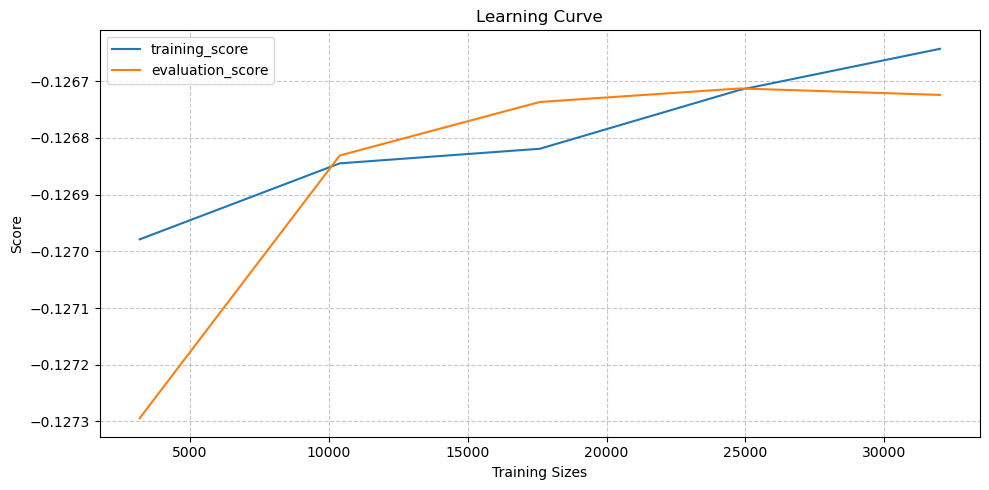

In [4]:
ax = utils.modeling.plot_learning_curve(
    estimator=lr_model,
    X_train=X_train_scaled,
    y_train=y_train,
    train_sizes=np.linspace(0.1, 1, 5),
    cv=5,
    scoring="neg_mean_absolute_error"
)

In [84]:
def importance_sign(importance):
    if importance > 0:
        return "Positive"
    else:
        return "negative"

importances = pd.DataFrame(
	data=lr_model.coef_,
    index=data["features"],
    columns=["feature_importance"]
)
importances['abs_feature_importance'] = abs(lr_model.coef_)
importances['sign'] = importances['feature_importance'].apply(importance_sign)
importances = importances.sort_values(by="abs_feature_importance")

importances

,feature_importance,abs_feature_importance,sign
tool_diversity,0.000558,0.000558,Positive
weekly_genai_hours,0.000602,0.000602,Positive
major_category_humanities,0.001096,0.001096,Positive
skill_retention_score,0.001181,0.001181,Positive
perceived_ai_dependency,-0.001355,0.001355,negative
major_category_stem,-0.001440,0.001440,negative
major_category_business,-0.001817,0.001817,negative
burnout_risk_level,-0.002196,0.002196,negative
anxiety_level_during_exams,-0.003644,0.003644,negative
major_category_medical,0.004232,0.004232,Positive


Text(0.03, 5, '(features with an importance under 0.5 are not important)')

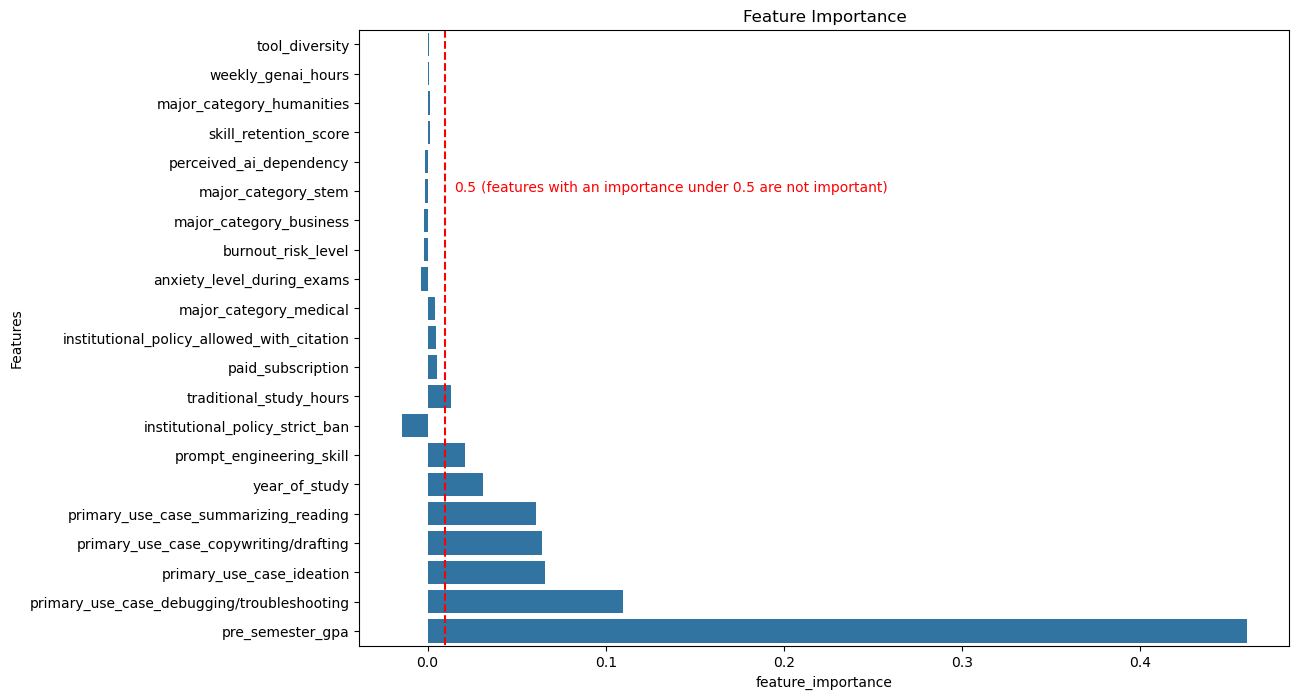

In [101]:
plt.figure(figsize=(12, 8))
sns.barplot(
    data=importances,
    y=importances.index,
    x="feature_importance"
)

plt.title("Feature Importance")
plt.ylabel("Features")
plt.vlines(x=0.01, ymin=-0.5, ymax=20.5, color="red", linestyle="--")
plt.ylim(20.5, -0.5)
plt.text(0.015, y=5, s="0.5", color="red")
plt.text(0.03, y=5, s="(features with an importance under 0.5 are not important)", color="red")

By looking at the feature importance plot it can be derived that these features has the most impact in the post semester GPA of a student:
- Pre Semester GPA
- Primary Use Case of AI: debugging/troubleshooting, ideation, copywriting/drafting, summarizing/drafting
- Year of Study
- Prompt Engineering Skill
- Institutional Policy: strict ban
- Traditional Study Hours

In [91]:
print("-" * 50)
print("Important Features:")
print("-" * 50)
importances[importances['abs_feature_importance'] > 0.01]

--------------------------------------------------
Important Features:
--------------------------------------------------


,feature_importance,abs_feature_importance,sign
traditional_study_hours,0.013310,0.013310,Positive
institutional_policy_strict_ban,-0.014537,0.014537,negative
prompt_engineering_skill,0.021042,0.021042,Positive
year_of_study,0.030867,0.030867,Positive
primary_use_case_summarizing_reading,0.060897,0.060897,Positive
primary_use_case_copywriting/drafting,0.064173,0.064173,Positive
primary_use_case_ideation,0.065694,0.065694,Positive
primary_use_case_debugging/troubleshooting,0.109661,0.109661,Positive
pre_semester_gpa,0.459831,0.459831,Positive


- Based-on the feature importance we can say institutional policy that strictly ban the usage of AI is more likely to have negative effect on the post semester GPA of the students.
- Primary use case of AI for debugging/troubleshooting is more likely to have more positive effect on the post semester GPA than other primary use cases like ideation, copywriting/drafting, summarizing reading, etc.

In [92]:
from sklearn.ensemble import RandomForestRegressor

random_forest = RandomForestRegressor()
random_forest.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the numb

In [94]:
utils.modeling.print_regression_evalutaion_metrics(random_forest, X_test_scaled, y_test)

,Metrics
Mean Squared Error,0.024604
Root Mean Squared Error,0.156857
Mean Absolute Error,0.122014
R-Square (Goodness of Fit),0.898072


In [99]:
random_forest_importances = pd.DataFrame(
	data=random_forest.feature_importances_,
    index=data["features"],
    columns=["feature_importance"]
)
random_forest_importances = random_forest_importances.sort_values(by="feature_importance")

random_forest_importances

,feature_importance
major_category_medical,0.001029
primary_use_case_summarizing_reading,0.001081
primary_use_case_ideation,0.001171
major_category_humanities,0.001201
primary_use_case_copywriting/drafting,0.001236
major_category_business,0.001301
institutional_policy_strict_ban,0.001368
major_category_stem,0.001481
institutional_policy_allowed_with_citation,0.001580
paid_subscription,0.001792


Text(0, 0.5, 'Features')

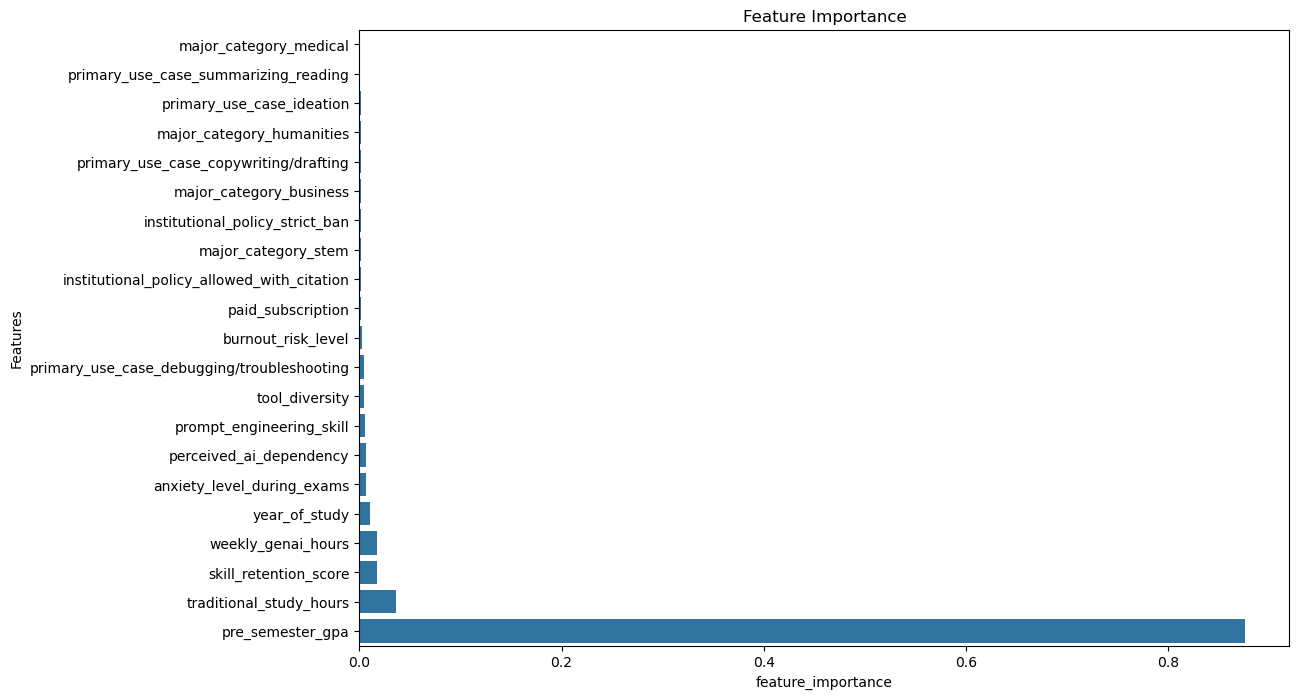

In [104]:
plt.figure(figsize=(12, 8))
sns.barplot(
    data=random_forest_importances,
    y=random_forest_importances.index,
    x="feature_importance"
)

plt.title("Feature Importance")
plt.ylabel("Features")

In [105]:
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import VotingRegressor, BaggingRegressor, AdaBoostRegressor, StackingRegressor
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor